# 대전 생활물류 거점 입지 선정 프로젝트 
 **공모전 :**대전 물류데이터 AI 활용 및 분석 아이디어 공모전
 **작성자:** 신도윤
 ## 목표 
 공동주택,인구,택배물량 데이터를 활용하여 
 생활물류 수요를 분석하고 
 공동배송 거점 후보지를 추천한다
 

In [1]:
import pandas as pd 
import os

## 1.데이터 불러오기


In [2]:
raw_path = "../data/raw"

files = os.listdir(raw_path)

files

['과학기술정보통신부 우정사업본부_전국 우편번호(배달지 기준)별 택배물량_20231231.csv',
 '대전광역시 대덕구_공동주택현황_20250831.csv',
 '대전광역시 동구_공동주택현황_20250410.csv',
 '대전광역시 서구_공동주택 현황_20250819.csv',
 '대전광역시 서구_동별 성별 인구수 추이_20230430.csv',
 '대전광역시 유성구_공동주택 현황_20260609.csv',
 '대전광역시 유성구_인구통계 현황_20250630.csv',
 '통계_년간물류창고업등록현황_260731.xls',
 '통계_면적별물류창고업등록현황_260731.xls',
 '통계_지역별물류창고업등록현황_260731.xls']

## 2.공동주택 데이터 확인
대전광역시 동구,서구,유성구,대덕구 공동주택 데이터의 컬럼명,데이터 크기,상위 5개 행을 확인한다.

In [5]:
def read_csv_auto(path):
    encodings = ["cp949", "utf-8", "utf-8-sig", "euc-kr"]

    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"성공! 인코딩: {enc}")
            return df
        except Exception:
            pass

    raise ValueError(f"파일을 읽을 수 없습니다.\n{path}")

In [6]:
donggu = read_csv_auto(
    "../data/raw/대전광역시 동구_공동주택현황_20250410.csv"
)

print("데이터 크기:", donggu.shape)
print("컬럼명:", donggu.columns.tolist())

donggu.head()

성공! 인코딩: cp949
데이터 크기: (156, 6)
컬럼명: ['연번', '공동주택명', '위치', '층수', '동수', '세대수']


,연번,공동주택명,위치,층수,동수,세대수
0,1,현대아파트,대전광역시 동구 계족로443번길 24(용전동),4,1,48
1,2,용전서민아파트,대전광역시 동구 계족로 485-35(용전동),4,2,112
2,3,삼성아파트A동,대전광역시 동구 선화로 183(삼성동),5,1,45
3,4,삼성아파트B동,대전광역시 동구 대전천동로 612(삼성동),5,1,40
4,5,가양글로벌아파트,대전광역시 동구 동서대로1778번길 122(가양동),5,1,40


In [7]:
seogu = read_csv_auto(
    "../data/raw/대전광역시 서구_공동주택 현황_20250819.csv"
)

print("데이터 크기:", seogu.shape)
print("컬럼명:", seogu.columns.tolist())

seogu.head()

성공! 인코딩: utf-8
데이터 크기: (293, 16)
컬럼명: ['순번', '공동주택명', '위치', '지번주소', '도로명주소', '행정동명', '행정동코드', '법정동명', '법정동코드', '층수', '동수', '세대수', '사용승인일', '의무관리대상여부', '공동주택구분', '비고']


,순번,공동주택명,위치,지번주소,도로명주소,행정동명,행정동코드,법정동명,법정동코드,층수,동수,세대수,사용승인일,의무관리대상여부,공동주택구분,비고
0,1,성신연립,도마동334-2,대전광역시 서구 도마동334-2,대전광역시 서구 배재로91번길 8,도마2동,3017053000,도마동,3017010300,0/4,2,30,1979-08-17,비의무,연립주택,NaN
1,2,삼성연립,도마동 91-28,대전광역시 서구 도마동 91-28,대전광역시 서구 도마9길 23,도마1동,3017052000,도마동,3017010300,01월 02일,3,24,1980-01-07,비의무,아파트,NaN
2,3,금강연립,도마동 130-7,대전광역시 서구 도마동 130-7,대전광역시 서구 도마4길 37,도마1동,3017052000,도마동,3017010300,01월 02일,3,24,1980-09-09,비의무,아파트,NaN
3,4,초원연립,변동 62-8,대전광역시 서구 변동 62-8,대전광역시 서구 도산로 164,변동,3017054000,변동,3017010200,01월 03일,2,36,1980-10-17,비의무,아파트,NaN
4,5,대중,내동 39-20 외2,대전광역시 서구 내동 39-20 외2,대전광역시 서구 갈마로212번길 29,내동,3017057500,내동,3017011000,01월 03일,2,30,1980-12-23,비의무,아파트,NaN


In [8]:
yuseong = read_csv_auto(
    "../data/raw/대전광역시 유성구_공동주택 현황_20260609.csv"
)

print("유성구 데이터 크기:", yuseong.shape)
print("유성구 컬럼명:", yuseong.columns.tolist())

yuseong.head()

성공! 인코딩: cp949
유성구 데이터 크기: (257, 7)
유성구 컬럼명: ['공동주택명', '소재지지번주소', '소재지도로명주소', '세대수', '사용승인일', '공동주택구분', '데이터기준일']


,공동주택명,소재지지번주소,소재지도로명주소,세대수,사용승인일,공동주택구분,데이터기준일
0,원자력연료사원아파트,대전광역시 유성구 도룡동 392-2,대전광역시 유성구 대덕대로577번길 51(도룡동한전원전사택),81,1986-04-16,아파트,2026-06-09
1,우성아파트,대전광역시 유성구 도룡동 383-3,대전광역시 유성구 문지로 22(도룡동우성아파트),55,1989-06-13,아파트,2026-06-09
2,연구원 현대아파트,대전광역시 유성구 도룡동 431-6,대전광역시 유성구 대덕대로541번길 68(도룡동대덕연구원현대아파트),150,1989-10-12,아파트,2026-06-09
3,과기원교수아파트,대전광역시 유성구 도룡동 383-2,대전광역시 유성구 문지로 14(도룡동카이스트교수아파트),76,1990-09-18,아파트,2026-06-09
4,삼정하이츠아파트,대전광역시 유성구 구암동 600-2,대전광역시 유성구 유성대로668번길 29(구암동삼정하이츠),150,1991-12-17,아파트,2026-06-09


In [9]:
daedeok = read_csv_auto(
    "../data/raw/대전광역시 대덕구_공동주택현황_20250831.csv"
)

print("대덕구 데이터 크기:", daedeok.shape)
print("대덕구 컬럼명:", daedeok.columns.tolist())

daedeok.head()

성공! 인코딩: utf-8
대덕구 데이터 크기: (166, 9)
대덕구 컬럼명: ['아파트단지명', '단지코드', '동수', '법정동주소', '도로명주소', '층수', '세대수', '사용검사일자', '데이터기준일자']


,아파트단지명,단지코드,동수,법정동주소,도로명주소,층수,세대수,사용검사일자,데이터기준일자
0,금강아파트,NaN,2,대전광역시 대덕구 대화동 27-7,대전광역시 대덕구 대전로 1247(대화동),5,90,1978-08-04,2025-08-31
1,신진연립,NaN,3,대전광역시 대덕구 신탄진동 122-17,대전광역시 대덕구 신탄진동로35번길 63(신탄진동),2~3,31,1978-11-21,2025-08-31
2,대화아파트,NaN,1,대전광역시 대덕구 대화동 40-67,대전광역시 대덕구 대화로 53(대화동),5,50,1979-03-30,2025-08-31
3,흥일아파트,NaN,1,대전광역시 대덕구 송촌동 291-9,대전광역시 대덕구 송촌남로 50(송촌동),6,40,1979-05-30,2025-08-31
4,세림연립,NaN,3,대전광역시 대덕구 덕암동 15-3,대전광역시 대덕구 덕암북로96번길 22-14(덕암동),2,28,1979-06-26,2025-08-31


# 3.공동주택 데이터 전처리 및 통합

In [10]:
print("동구:", donggu.columns.tolist())
print("서구:", seogu.columns.tolist())
print("유성구:", yuseong.columns.tolist())
print("대덕구:", daedeok.columns.tolist())

동구: ['연번', '공동주택명', '위치', '층수', '동수', '세대수']
서구: ['순번', '공동주택명', '위치', '지번주소', '도로명주소', '행정동명', '행정동코드', '법정동명', '법정동코드', '층수', '동수', '세대수', '사용승인일', '의무관리대상여부', '공동주택구분', '비고']
유성구: ['공동주택명', '소재지지번주소', '소재지도로명주소', '세대수', '사용승인일', '공동주택구분', '데이터기준일']
대덕구: ['아파트단지명', '단지코드', '동수', '법정동주소', '도로명주소', '층수', '세대수', '사용검사일자', '데이터기준일자']


### 3-1.컬럼명 통일

In [11]:
donggu = donggu.rename(columns={
    "공동주택명": "공동주택명",
    "위치": "주소",
    "세대수": "세대수"
})

donggu = donggu[["공동주택명", "주소", "세대수"]]
donggu["구"] = "동구"

donggu.head()

,공동주택명,주소,세대수,구
0,현대아파트,대전광역시 동구 계족로443번길 24(용전동),48,동구
1,용전서민아파트,대전광역시 동구 계족로 485-35(용전동),112,동구
2,삼성아파트A동,대전광역시 동구 선화로 183(삼성동),45,동구
3,삼성아파트B동,대전광역시 동구 대전천동로 612(삼성동),40,동구
4,가양글로벌아파트,대전광역시 동구 동서대로1778번길 122(가양동),40,동구


In [12]:
seogu = seogu.rename(columns={
    "공동주택명": "공동주택명",
    "도로명주소": "주소",
    "세대수": "세대수"
})

seogu = seogu[["공동주택명", "주소", "세대수"]]
seogu["구"] = "서구"

seogu.head()

,공동주택명,주소,세대수,구
0,성신연립,대전광역시 서구 배재로91번길 8,30,서구
1,삼성연립,대전광역시 서구 도마9길 23,24,서구
2,금강연립,대전광역시 서구 도마4길 37,24,서구
3,초원연립,대전광역시 서구 도산로 164,36,서구
4,대중,대전광역시 서구 갈마로212번길 29,30,서구


In [13]:
yuseong = yuseong.rename(columns={
    "공동주택명": "공동주택명",
    "소재지도로명주소": "주소",
    "세대수": "세대수"
})

yuseong = yuseong[["공동주택명", "주소", "세대수"]]
yuseong["구"] = "유성구"

yuseong.head()

,공동주택명,주소,세대수,구
0,원자력연료사원아파트,대전광역시 유성구 대덕대로577번길 51(도룡동한전원전사택),81,유성구
1,우성아파트,대전광역시 유성구 문지로 22(도룡동우성아파트),55,유성구
2,연구원 현대아파트,대전광역시 유성구 대덕대로541번길 68(도룡동대덕연구원현대아파트),150,유성구
3,과기원교수아파트,대전광역시 유성구 문지로 14(도룡동카이스트교수아파트),76,유성구
4,삼정하이츠아파트,대전광역시 유성구 유성대로668번길 29(구암동삼정하이츠),150,유성구


In [14]:
daedeok = daedeok.rename(columns={
    "아파트단지명": "공동주택명",
    "도로명주소": "주소",
    "세대수": "세대수"
})

daedeok = daedeok[["공동주택명", "주소", "세대수"]]
daedeok["구"] = "대덕구"

daedeok.head()

,공동주택명,주소,세대수,구
0,금강아파트,대전광역시 대덕구 대전로 1247(대화동),90,대덕구
1,신진연립,대전광역시 대덕구 신탄진동로35번길 63(신탄진동),31,대덕구
2,대화아파트,대전광역시 대덕구 대화로 53(대화동),50,대덕구
3,흥일아파트,대전광역시 대덕구 송촌남로 50(송촌동),40,대덕구
4,세림연립,대전광역시 대덕구 덕암북로96번길 22-14(덕암동),28,대덕구


### 3-2. 공동주택 데이터 통합

동구, 서구, 유성구, 대덕구의 공동주택 데이터를
동일한 컬럼 구조로 통일한 후 하나의 데이터프레임으로 통합한다.

최종 데이터셋은 이후 인구 데이터 병합, 공간 분석,
생활물류 수요 분석의 기초 데이터로 활용된다.

In [15]:
apt_all = pd.concat(
    [donggu, seogu, yuseong, daedeok],
    ignore_index=True
)

apt_all.head()

,공동주택명,주소,세대수,구
0,현대아파트,대전광역시 동구 계족로443번길 24(용전동),48,동구
1,용전서민아파트,대전광역시 동구 계족로 485-35(용전동),112,동구
2,삼성아파트A동,대전광역시 동구 선화로 183(삼성동),45,동구
3,삼성아파트B동,대전광역시 동구 대전천동로 612(삼성동),40,동구
4,가양글로벌아파트,대전광역시 동구 동서대로1778번길 122(가양동),40,동구


In [16]:
print("총 데이터 개수 :", len(apt_all))
print()

apt_all.info()

총 데이터 개수 : 872

<class 'pandas.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   공동주택명   872 non-null    str  
 1   주소      872 non-null    str  
 2   세대수     872 non-null    int64
 3   구       872 non-null    str  
dtypes: int64(1), str(3)
memory usage: 97.0 KB


In [17]:
apt_all.to_csv(
    "../data/processed/apt_all.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료!")

저장 완료!


# 4. 공동주택 데이터 탐색적 분석(EDA)

통합된 공동주택 데이터의 구조, 결측치, 중복값, 기초통계량을 확인한다.

In [18]:
print("데이터 크기:", apt_all.shape)

print("\n컬럼별 결측치")
print(apt_all.isnull().sum())

print("\n중복 행 개수")
print(apt_all.duplicated().sum())

print("\n세대수 기초통계")
display(apt_all["세대수"].describe())

데이터 크기: (872, 4)

컬럼별 결측치
공동주택명    0
주소       0
세대수      0
구        0
dtype: int64

중복 행 개수
0

세대수 기초통계


count     872.000000
mean      402.780963
std       505.038150
min         6.000000
25%        51.000000
50%       152.000000
75%       641.250000
max      3958.000000
Name: 세대수, dtype: float64

### 4-1. 공동주택 분포 시각화

In [20]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

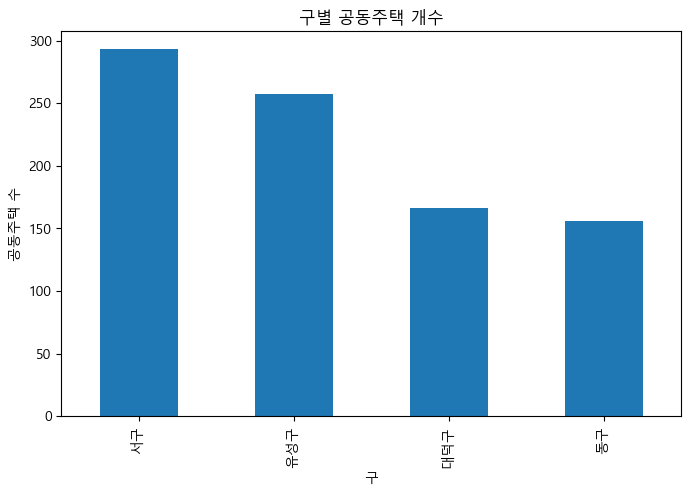

In [21]:
import matplotlib.pyplot as plt

apt_all["구"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("구별 공동주택 개수")
plt.xlabel("구")
plt.ylabel("공동주택 수")

plt.show()

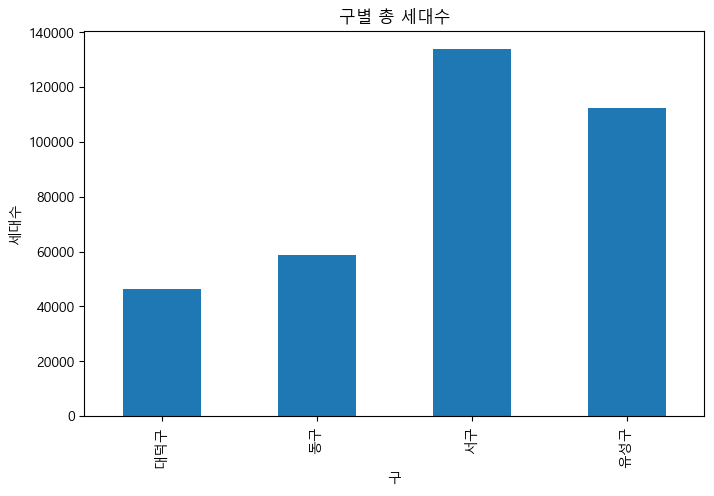

In [22]:
apt_all.groupby("구")["세대수"].sum().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("구별 총 세대수")
plt.xlabel("구")
plt.ylabel("세대수")

plt.show()

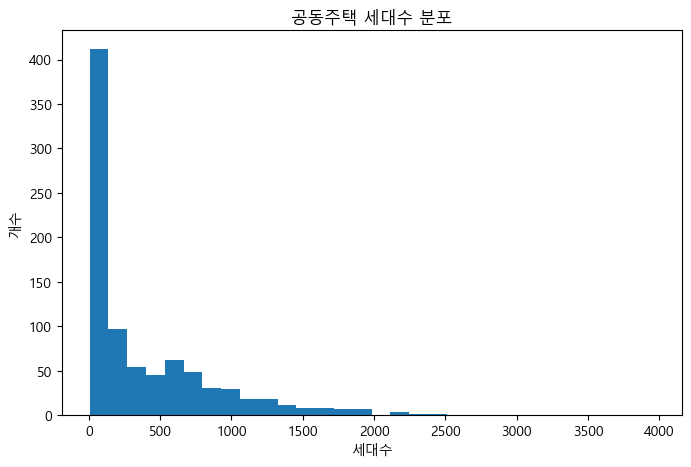

In [23]:
plt.figure(figsize=(8,5))

plt.hist(apt_all["세대수"], bins=30)

plt.title("공동주택 세대수 분포")
plt.xlabel("세대수")
plt.ylabel("개수")

plt.show()

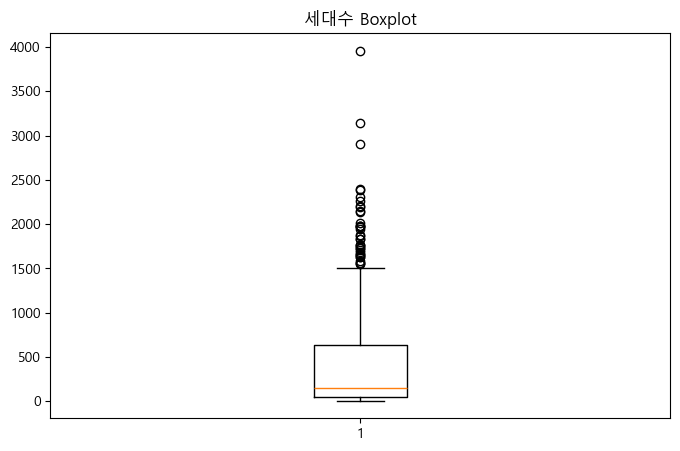

In [24]:
plt.figure(figsize=(8,5))

plt.boxplot(apt_all["세대수"])

plt.title("세대수 Boxplot")

plt.show()

공동주택 세대수는 소규모 단지에 집중되어 있지만 일부 대규모 단지가 존재하며 이러한 대단지는 생활 물류 수요 집중지역을 판단하는데 
중요한 요소가 될수 있다.

# 5. 구별 공동주택 세대수 분석

In [25]:
# 구별 총 세대수

apt_all.groupby("구")["세대수"].sum().sort_values(ascending=False)

구
서구     133741
유성구    112366
동구      58770
대덕구     46348
Name: 세대수, dtype: int64

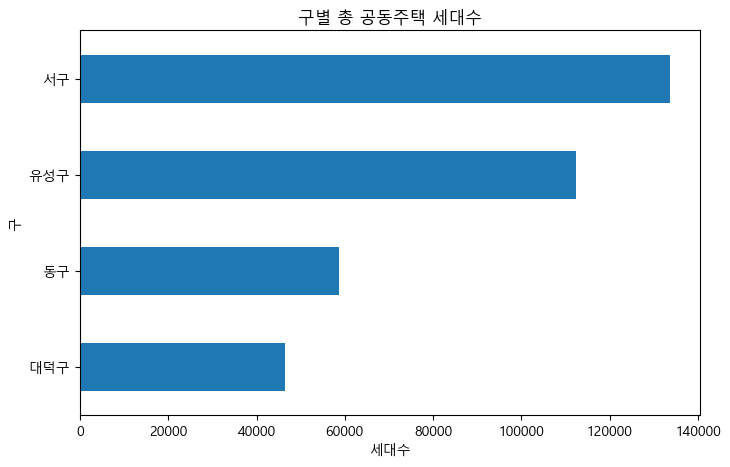

In [26]:
import matplotlib.pyplot as plt

total = apt_all.groupby("구")["세대수"].sum().sort_values()

plt.figure(figsize=(8,5))

total.plot(kind="barh")

plt.title("구별 총 공동주택 세대수")
plt.xlabel("세대수")
plt.ylabel("구")

plt.show()

# 6. 대전 공동주택 규모 TOP20

In [27]:
top20 = apt_all.sort_values(
    by="세대수",
    ascending=False
)

top20.head(20)

,공동주택명,주소,세대수,구
461,엑스포아파트,대전광역시 유성구 엑스포로 448(전민동엑스포아파트),3958,유성구
455,한빛아파트,대전광역시 유성구 어은로 57(어은동한빛아파트),3144,유성구
263,큰마을,대전광역시 서구 대덕대로 150,2910,서구
297,래미안,대전광역시 서구 가장로 106,2398,서구
149,대전판암4 (주공),대전광역시 동구 동부로 56-7(판암동),2384,동구
839,금강엑슬루타워,대전광역시 대덕구 대덕대로 1555(석봉동),2312,대덕구
82,e편한세상 대전에코포레아파트,대전광역시 동구 용운로 203(용운동),2267,동구
279,샘머리2단지,대전광역시 서구 청사로 281,2200,서구
320,맑은아침,대전광역시 서구 갈마로 262,2199,서구
129,판암주공1차2차,대전광역시 동구 옥천로180번길 47-2(판암동),2146,동구


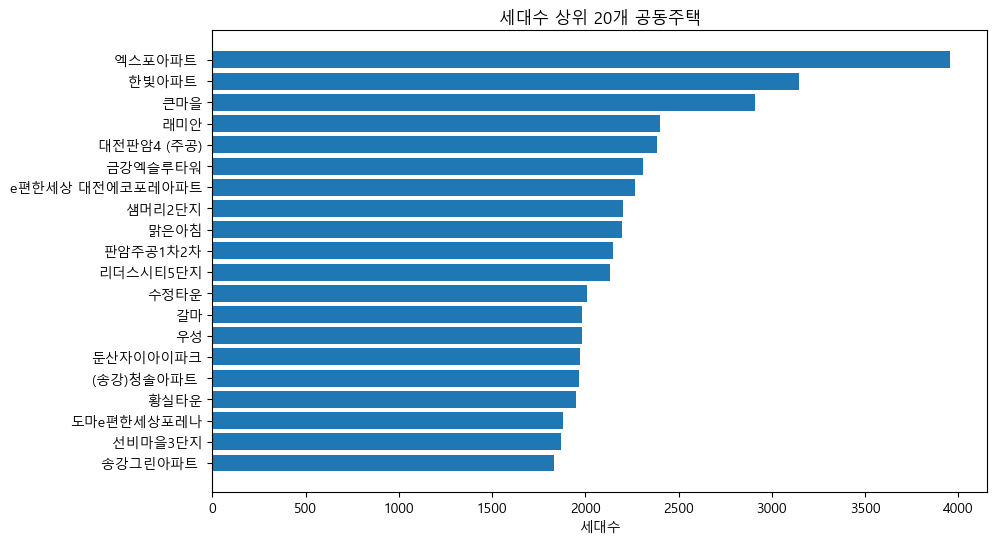

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    top20.head(20)["공동주택명"],
    top20.head(20)["세대수"]
)

plt.title("세대수 상위 20개 공동주택")

plt.xlabel("세대수")

plt.gca().invert_yaxis()

plt.show()

# 7.행정동별 공동주택 집계

### 7-1.주소 컬럼 랜덤 샘플 확인
상세주소까지 들어있으면 그룹핑이 중구난방이 되고 전부 따로 되어버린다 원하는 행정동 집계는 도마동,탄방동 이런식으로 행정동 단위이기 때문에 모든 컬럼을 다 보기 어려우니까 샘플링방식을 활용한다.

In [29]:
apt_all["주소"].sample(30,random_state=42)


794               대전광역시 대덕구 신탄진남로 26(신탄진동)
319                    대전광역시 서구 문정로2번길 123
382                       대전광역시 서구 도안동로 77
779             대전광역시 대덕구 덕암북로10번길 31(덕암동)
422                   대전광역시 서구 도솔로388번길 52
327                    대전광역시 서구 문정로2번길 109
803             대전광역시 대덕구 대청로64번길 41(신탄진동)
136                   대전광역시 동구 대전로 646(효동)
670        대전광역시 유성구 대학로 39-10(봉명동엔터팰리스1차)
810              대전광역시 대덕구 덕암로154번길 6(상서동)
323                        대전광역시 서구 탄방로 12
344                        대전광역시 서구 탄방로 10
497    대전광역시 유성구 왕가봉로 23(노은동열매마을계룡리슈빌11단지)
227                      대전광역시 서구 둔산북로 160
44                대전광역시 동구 동부로85번길 12(용운동)
404                       대전광역시 서구 관저중로 33
210                       대전광역시 서구 둔산로 223
428                   대전광역시 서구 계룡로615번길 82
444                       대전광역시 서구 탄방로 132
174                       대전광역시 서구 중반9길 23
70              대전광역시 동구 동서대로 1669-12(용전동)
462           대전광역시 유성구 봉산로 45(송강동송강마을1단지)
465           대전광역시 유성구 엑스포로 501(전민동나래아파트)
309        

층화 샘플링 (stratified sampling )

In [30]:
apt_all.groupby("구",group_keys=False).apply(lambda x: x.sample(5,random_state=42))

,공동주택명,주소,세대수
806,보람아파트,대전광역시 대덕구 동춘당로 178(법동),1735
842,시그마빌,대전광역시 대덕구 송촌로 34(송촌동),20
784,현대아파트,대전광역시 대덕구 계족로761번길 24(읍내동),1344
762,대원아파트,대전광역시 대덕구 신탄진로681번길 11(평촌동),45
803,새여울(대우)아파트,대전광역시 대덕구 대청로64번길 41(신탄진동),300
96,솔랑마을,대전광역시 동구 대전로 968(삼성동),253
69,트윈스아파트9차,대전광역시 동구 동서대로1748번길 75(가양동),19
82,e편한세상 대전에코포레아파트,대전광역시 동구 용운로 203(용운동),2267
76,올인하우징 1동,대전광역시 동구 선화로192번길 39(중동),7
114,은어송마을3단지,대전광역시 동구 은어송로 117(가오동),696


# 8.대전 행정동별 인구현황 집계
행정동 명 이름이 정확하게 정리가 안되있고 결측인 파일들이 많다.파일구조에서 확인할 수 있듯이 특정 구는 인구 csv나 액셀이 존재하고 특정 구는 존재하지 않는다.그래서 population 폴더와 boundary 폴더와 apartment 폴더를 만들어서 무의미하거나 불균형한 데이터 분석이랑 전처리가 되지 않게 처리 하였다.

In [31]:
import pandas as pd

population_path = "../data/raw/population/2. 2025년 12월말 구별 동별 연령별5세단위 인구현황.xlsx"

population_raw = pd.read_excel(
    population_path,
    sheet_name="연령별인구현황",
    header=1
)

print("데이터 크기:", population_raw.shape)
print("\n컬럼:")
print(population_raw.columns.tolist())

population_raw.head()

데이터 크기: (88, 71)

컬럼:
['행정기관코드', '행정기관', '총 인구수', '연령구간인구수', '0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세', '35~39세', '40~44세', '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85~89세', '90~94세', '95~99세', '100세 이상', '남 인구수', '연령구간인구수.1', '0~4세.1', '5~9세.1', '10~14세.1', '15~19세.1', '20~24세.1', '25~29세.1', '30~34세.1', '35~39세.1', '40~44세.1', '45~49세.1', '50~54세.1', '55~59세.1', '60~64세.1', '65~69세.1', '70~74세.1', '75~79세.1', '80~84세.1', '85~89세.1', '90~94세.1', '95~99세.1', '100세 이상.1', '여 인구수', '연령구간인구수.2', '0~4세.2', '5~9세.2', '10~14세.2', '15~19세.2', '20~24세.2', '25~29세.2', '30~34세.2', '35~39세.2', '40~44세.2', '45~49세.2', '50~54세.2', '55~59세.2', '60~64세.2', '65~69세.2', '70~74세.2', '75~79세.2', '80~84세.2', '85~89세.2', '90~94세.2', '95~99세.2', '100세 이상.2']


,행정기관코드,행정기관,총 인구수,연령구간인구수,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,...,55~59세.2,60~64세.2,65~69세.2,70~74세.2,75~79세.2,80~84세.2,85~89세.2,90~94세.2,95~99세.2,100세 이상.2
0,3000000000,대전광역시,"1,440,729","1,440,729","38,115","48,661","66,153","69,594","82,973","104,729",...,"60,409","55,421","52,025","36,302","25,905","19,477","12,264","5,271","1,279",176
1,3011000000,대전광역시 동구,"218,664","218,664","5,185","5,944","8,266","10,084","14,456","13,503",...,"8,713","8,768","9,231","6,988","5,339","4,131","2,561","1,012",235,28
2,3011051500,대전광역시 동구 중앙동,"3,319","3,319",22,28,38,50,71,144,...,96,129,185,179,156,130,67,30,10,0
3,3011053000,대전광역시 동구 효동,"29,264","29,264","1,318","1,254","1,703","1,766","1,338","1,343",...,"1,055",913,965,678,505,328,194,88,20,4
4,3011054500,대전광역시 동구 신인동,"14,713","14,713",550,506,545,512,553,755,...,622,590,672,525,351,266,152,51,21,1


### 8. 대전광역시 데이터만 추출 후  숫자형으로 변경

In [32]:
population = population_raw.copy()

# 행정기관코드를 문자열로 변환
population["행정기관코드"] = population["행정기관코드"].astype(str)

# 대전광역시 데이터만 선택
population = population[
    population["행정기관"].astype(str).str.startswith("대전광역시")
].copy()

# 숫자형으로 바꿀 컬럼
numeric_cols = [
    "총 인구수",
    "0~4세",
    "5~9세",
    "10~14세",
    "15~19세",
    "20~24세",
    "25~29세",
    "30~34세",
    "35~39세",
    "40~44세",
    "45~49세",
    "50~54세",
    "55~59세",
    "60~64세",
    "65~69세",
    "70~74세",
    "75~79세",
    "80~84세",
    "85~89세",
    "90~94세",
    "95~99세",
    "100세 이상"
]

for col in numeric_cols:
    population[col] = (
        population[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", pd.NA)
        .astype("Int64")
    )

population.head()

,행정기관코드,행정기관,총 인구수,연령구간인구수,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,...,55~59세.2,60~64세.2,65~69세.2,70~74세.2,75~79세.2,80~84세.2,85~89세.2,90~94세.2,95~99세.2,100세 이상.2
0,3000000000,대전광역시,1440729,"1,440,729",38115,48661,66153,69594,82973,104729,...,"60,409","55,421","52,025","36,302","25,905","19,477","12,264","5,271","1,279",176
1,3011000000,대전광역시 동구,218664,"218,664",5185,5944,8266,10084,14456,13503,...,"8,713","8,768","9,231","6,988","5,339","4,131","2,561","1,012",235,28
2,3011051500,대전광역시 동구 중앙동,3319,"3,319",22,28,38,50,71,144,...,96,129,185,179,156,130,67,30,10,0
3,3011053000,대전광역시 동구 효동,29264,"29,264",1318,1254,1703,1766,1338,1343,...,"1,055",913,965,678,505,328,194,88,20,4
4,3011054500,대전광역시 동구 신인동,14713,"14,713",550,506,545,512,553,755,...,622,590,672,525,351,266,152,51,21,1


In [33]:
# 행정동 코드: 대전광역시 30으로 시작하며 끝 네 자리가 0000이 아닌 행
population_dong = population[
    ~population["행정기관코드"].str.endswith("0000")
].copy()

population_dong[["행정기관코드", "행정기관", "총 인구수"]].head(10)

,행정기관코드,행정기관,총 인구수
2,3011051500,대전광역시 동구 중앙동,3319
3,3011053000,대전광역시 동구 효동,29264
4,3011054500,대전광역시 동구 신인동,14713
5,3011055100,대전광역시 동구 판암1동,11650
6,3011055200,대전광역시 동구 판암2동,7647
7,3011056000,대전광역시 동구 용운동,20851
8,3011058500,대전광역시 동구 대동,13347
9,3011059000,대전광역시 동구 자양동,10641
10,3011062000,대전광역시 동구 가양1동,12664
11,3011063000,대전광역시 동구 가양2동,17893


In [34]:
population_dong["구"] = (
    population_dong["행정기관"]
    .str.extract(r"대전광역시\s+(\S+구)")
)

population_dong["행정동"] = (
    population_dong["행정기관"]
    .str.extract(r"대전광역시\s+\S+구\s+(.+)")
)

population_dong[
    ["행정기관코드", "구", "행정동", "총 인구수"]
].head(10)

,행정기관코드,구,행정동,총 인구수
2,3011051500,동구,중앙동,3319
3,3011053000,동구,효동,29264
4,3011054500,동구,신인동,14713
5,3011055100,동구,판암1동,11650
6,3011055200,동구,판암2동,7647
7,3011056000,동구,용운동,20851
8,3011058500,동구,대동,13347
9,3011059000,동구,자양동,10641
10,3011062000,동구,가양1동,12664
11,3011063000,동구,가양2동,17893


In [35]:
population_processed = population_dong[
    [
        "행정기관코드",
        "구",
        "행정동",
        "총 인구수",
        "0~4세",
        "5~9세",
        "10~14세",
        "15~19세",
        "20~24세",
        "25~29세",
        "30~34세",
        "35~39세",
        "40~44세",
        "45~49세",
        "50~54세",
        "55~59세",
        "60~64세",
        "65~69세",
        "70~74세",
        "75~79세",
        "80~84세",
        "85~89세",
        "90~94세",
        "95~99세",
        "100세 이상"
    ]
].copy()

population_processed.to_csv(
    "../data/processed/population_dong.csv",
    index=False,
    encoding="utf-8-sig"
)

print(population_processed.shape)
population_processed.head()

(78, 25)


,행정기관코드,구,행정동,총 인구수,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
2,3011051500,동구,중앙동,3319,22,28,38,50,71,144,...,298,411,433,369,288,208,105,42,12,0
3,3011053000,동구,효동,29264,1318,1254,1703,1766,1338,1343,...,2111,1689,1775,1225,899,566,312,109,23,4
4,3011054500,동구,신인동,14713,550,506,545,512,553,755,...,1187,1090,1152,905,662,456,221,79,25,3
5,3011055100,동구,판암1동,11650,247,270,341,424,431,672,...,1071,1086,1169,793,584,497,303,139,19,4
6,3011055200,동구,판암2동,7647,35,87,121,166,179,331,...,644,845,984,806,649,484,319,106,20,0


### 8.행정동 별 확인 

In [36]:
population_dong.groupby("구")["행정동"].count()

구
대덕구    11
동구     16
서구     23
유성구    12
중구     16
Name: 행정동, dtype: int64

In [37]:
population_dong.groupby("구", group_keys=False).head(3)[
    ["행정기관코드", "구", "행정동", "총 인구수"]
]

,행정기관코드,구,행정동,총 인구수
2,3011051500,동구,중앙동,3319
3,3011053000,동구,효동,29264
4,3011054500,동구,신인동,14713
19,3014053500,중구,은행선화동,23966
20,3014055000,중구,목동,17354
21,3014056000,중구,중촌동,14884
37,3017051000,서구,복수동,20976
38,3017052000,서구,도마1동,17901
39,3017053000,서구,도마2동,19285
62,3020052000,유성구,진잠동,24930


In [38]:
population_processed = population_dong[
    [
        "행정기관코드",
        "구",
        "행정동",
        "총 인구수"
    ]
].copy()

In [39]:
population_processed.to_csv(
    "../data/processed/population_dong.csv",
    index=False,
    encoding="utf-8-sig"
)

print(population_processed.shape)
population_processed.head()

(78, 4)


,행정기관코드,구,행정동,총 인구수
2,3011051500,동구,중앙동,3319
3,3011053000,동구,효동,29264
4,3011054500,동구,신인동,14713
5,3011055100,동구,판암1동,11650
6,3011055200,동구,판암2동,7647


# 9.우체국 생활물류 전처리

In [42]:
from charset_normalizer import from_path

result = from_path(
    r"C:\Users\isebb\OneDrive\Desktop\Daejeon_Logistics_Project\data\raw\과학기술정보통신부 우정사업본부_전국 우편번호(배달지 기준)별 택배물량_20231231.csv"
).best()

print(result.encoding)

cp949


### 9-1.전국 우편 번호 읽기

In [43]:
post_raw = pd.read_csv(
    r"C:\Users\isebb\OneDrive\Desktop\Daejeon_Logistics_Project\data\raw\과학기술정보통신부 우정사업본부_전국 우편번호(배달지 기준)별 택배물량_20231231.csv",
    encoding="cp949"
)

post_raw.head()

,우편번호,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,1000,98,84,94,80,70,81,65,87,101,72,87,91
1,1001,253,219,299,283,284,273,263,262,278,287,286,294
2,1002,723,707,1059,939,997,945,849,844,897,920,898,848
3,1003,394,397,440,396,415,419,394,398,446,416,416,452
4,1004,281,238,304,305,322,341,267,257,302,311,330,313


In [46]:
post_raw.shape
post_raw.info()
post_raw.columns
post_raw.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 34502 entries, 0 to 34501
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   우편번호    34502 non-null  int64
 1   1월      34502 non-null  int64
 2   2월      34502 non-null  int64
 3   3월      34502 non-null  int64
 4   4월      34502 non-null  int64
 5   5월      34502 non-null  int64
 6   6월      34502 non-null  int64
 7   7월      34502 non-null  int64
 8   8월      34502 non-null  int64
 9   9월      34502 non-null  int64
 10  10월     34502 non-null  int64
 11  11월     34502 non-null  int64
 12  12월     34502 non-null  int64
dtypes: int64(13)
memory usage: 3.4 MB


,우편번호,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,1000,98,84,94,80,70,81,65,87,101,72,87,91
1,1001,253,219,299,283,284,273,263,262,278,287,286,294
2,1002,723,707,1059,939,997,945,849,844,897,920,898,848
3,1003,394,397,440,396,415,419,394,398,446,416,416,452
4,1004,281,238,304,305,322,341,267,257,302,311,330,313
5,1005,229,222,284,235,294,273,251,295,250,272,275,262
6,1006,469,444,562,478,492,499,458,447,459,442,486,503
7,1007,94,80,106,101,92,89,72,75,92,85,84,79
8,1008,138,107,120,139,143,113,94,94,110,116,117,113
9,1009,195,157,202,179,199,188,168,165,175,215,196,189


이 데이터는 생각했던 거랑 많이 다르다.우편번호별 택배 물량 데이터이다.우리가 가진 데이터는 공동주택->행정동,인구->행정동 인데
이건 우편번호 기준이다 행정동으로 바꿔주는 매핑데이터가 없으면 merge가 안된다. 우선 보류하고 상황봐서 기회가 될시 활용하면 될거같다

# 10. 물류 창고 전처리

우편번호별 택배물량 연간 물류창고 등록 현황 면적별 물류창고 등록 현황 다 사용 못하는 사용해도 분석에 큰 의미가 없는 데이터들이다.

# 11.우체국 정보 csv 다운로드 후 전처리 예정

In [49]:
import pandas as pd

postoffice_raw = pd.read_csv(
    "../data/raw/과학기술정보통신부 우정사업본부_우체국 정보 파일_20250301.csv",
    encoding="cp949"
)

postoffice_raw.head()

,우체국구분코드,우체국우편번호,관내우체국명,지방청명,총괄국명,우체국주소,우체국전화번호,우체국FAX번호,우편영업시간,금융영업시간
0,54213,59790,거문도우체국,전남청,여수우체국,전남 여수시 삼산면 거문길 28-8,061-666-8000,미운영,08:00~17:00,08:00~16:30
1,60462,48795,부산수정1동우편취급국,부산청,동부산우체국,부산 동구 고관로 41 (수정동),051-465-0062,051-465-0061,09:00~18:00,미운영
2,32897,27013,단양상진우편취급국,충청청,단양우체국,충북 단양군 단양읍 삼봉로 109(상진리),043-423-4411,043-423-3388,09:00~18:00,미운영
3,72373,38428,경일대학교우편취급국,경북청,경산우체국,경북 경산시 하양읍 가마실길 50(부호리33),053-600-4880,미운영,09:00~18:00,미운영
4,89869,4535,서울중앙우체국,서울청,서울중앙우체국,서울 중구 소공로 70 (충무로1가),02-6450-1114,02-6450-1730,09:00~18:00,09:00~16:30


# 데이터 구조 확인 및 컬럼명 확인

In [50]:
print("데이터 크기:", postoffice_raw.shape)
print("\n컬럼명:")
print(postoffice_raw.columns.tolist())

postoffice_raw.info()

데이터 크기: (3264, 10)

컬럼명:
['우체국구분코드', '우체국우편번호', '관내우체국명', '지방청명', '총괄국명', '우체국주소', '우체국전화번호', '우체국FAX번호', '우편영업시간', '금융영업시간']
<class 'pandas.DataFrame'>
RangeIndex: 3264 entries, 0 to 3263
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   우체국구분코드   3264 non-null   int64
 1   우체국우편번호   3264 non-null   int64
 2   관내우체국명    3264 non-null   str  
 3   지방청명      3264 non-null   str  
 4   총괄국명      3264 non-null   str  
 5   우체국주소     3264 non-null   str  
 6   우체국전화번호   3264 non-null   str  
 7   우체국FAX번호  3264 non-null   str  
 8   우편영업시간    3264 non-null   str  
 9   금융영업시간    3264 non-null   str  
dtypes: int64(2), str(8)
memory usage: 704.3 KB


# 대전 우체국 head 확인 

In [51]:
postoffice_daejeon = postoffice_raw[
    postoffice_raw["우체국주소"].str.startswith("대전", na=False)
].copy()

print("대전 우체국 수:", len(postoffice_daejeon))

postoffice_daejeon.head()

대전 우체국 수: 90


,우체국구분코드,우체국우편번호,관내우체국명,지방청명,총괄국명,우체국주소,우체국전화번호,우체국FAX번호,우편영업시간,금융영업시간
39,30419,34815,대전목동우체국,충청청,서대전우체국,대전 중구 동서대로 1411(목동),042-253-3005,042-257-1734,09:00~18:00,09:00~16:30
40,30428,35038,대전호동우체국,충청청,서대전우체국,대전 중구 대종로 150(호동),042-271-2005,042-283-0145,09:00~18:00,09:00~16:30
45,34408,35076,대전옥계동우편취급국,충청청,서대전우체국,대전 중구 모암로7번길 150(옥계동),042-283-9300,미운영,09:00~18:00,미운영
46,34417,34828,대전용두2동우편취급국,충청청,서대전우체국,대전 중구 동서대로1321번길 19(용두동),042-252-1544,042-252-5570,09:00~18:00,미운영
47,34453,35081,한밭산성우편취급국,충청청,서대전우체국,대전 중구 대둔산로 345(사정동),042-582-0090,042-582-1098,09:00~18:00,미운영


# 필요한 컬럼만 추출

In [52]:
postoffice_daejeon = postoffice_daejeon[
    [
        "관내우체국명",
        "우체국우편번호",
        "우체국주소",
        "우체국전화번호",
        "우편영업시간",
        "금융영업시간"
    ]
].copy()

postoffice_daejeon.head()

,관내우체국명,우체국우편번호,우체국주소,우체국전화번호,우편영업시간,금융영업시간
39,대전목동우체국,34815,대전 중구 동서대로 1411(목동),042-253-3005,09:00~18:00,09:00~16:30
40,대전호동우체국,35038,대전 중구 대종로 150(호동),042-271-2005,09:00~18:00,09:00~16:30
45,대전옥계동우편취급국,35076,대전 중구 모암로7번길 150(옥계동),042-283-9300,09:00~18:00,미운영
46,대전용두2동우편취급국,34828,대전 중구 동서대로1321번길 19(용두동),042-252-1544,09:00~18:00,미운영
47,한밭산성우편취급국,35081,대전 중구 대둔산로 345(사정동),042-582-0090,09:00~18:00,미운영


## 주소에서 구 추출

In [53]:
postoffice_daejeon["구"] = postoffice_daejeon["우체국주소"].str.extract(
    r"대전(?:광역시)?\s+(\S+구)"
)

postoffice_daejeon[
    ["관내우체국명", "우체국주소", "구"]
].head(10)

,관내우체국명,우체국주소,구
39,대전목동우체국,대전 중구 동서대로 1411(목동),중구
40,대전호동우체국,대전 중구 대종로 150(호동),중구
45,대전옥계동우편취급국,대전 중구 모암로7번길 150(옥계동),중구
46,대전용두2동우편취급국,대전 중구 동서대로1321번길 19(용두동),중구
47,한밭산성우편취급국,대전 중구 대둔산로 345(사정동),중구
193,대전유성우체국,대전 유성구 온천로 51 (봉명동),유성구
200,대전성모병원우편취급국,대전 중구 대흥로 64(대흥동),중구
260,대전둔산2동우체국,대전 서구 청사로 279 (둔산동),서구
261,대전만년동우체국,대전 서구 만년로 15 (만년동),서구
262,대전갈마동우체국,대전 서구 갈마중로50번길 5 (갈마동),서구


## 결측치와 중복 확인

In [54]:
print("결측치:")
display(postoffice_daejeon.isnull().sum())

print("중복 행 수:")
print(postoffice_daejeon.duplicated().sum())

print("구 추출 실패:")
display(
    postoffice_daejeon[
        postoffice_daejeon["구"].isna()
    ][["관내우체국명", "우체국주소"]]
)

결측치:


관내우체국명     0
우체국우편번호    0
우체국주소      0
우체국전화번호    0
우편영업시간     0
금융영업시간     0
구          0
dtype: int64

중복 행 수:
0
구 추출 실패:


,관내우체국명,우체국주소


## 구별 우체국 확인

In [55]:
postoffice_by_gu = (
    postoffice_daejeon
    .groupby("구")
    .size()
    .reset_index(name="우체국수")
    .sort_values("우체국수", ascending=False)
)

postoffice_by_gu

,구,우체국수
2,서구,26
3,유성구,17
1,동구,17
0,대덕구,15
4,중구,15


## 그래프로 확인


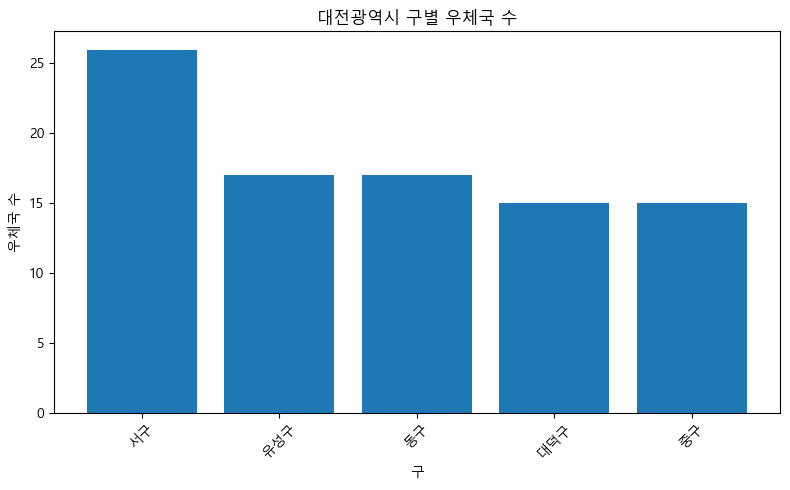

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    postoffice_by_gu["구"],
    postoffice_by_gu["우체국수"]
)

plt.title("대전광역시 구별 우체국 수")
plt.xlabel("구")
plt.ylabel("우체국 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 전처리 결과 저장

In [57]:
postoffice_daejeon.to_csv(
    "../data/processed/postoffice_daejeon.csv",
    index=False,
    encoding="utf-8-sig"
)

postoffice_by_gu.to_csv(
    "../data/processed/postoffice_by_gu.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


# 행정동 경계 geopandas로 불러오기 

In [58]:
%pip install geopandas folium mapclassify

   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ---------------------------------------- 882.2/882.2 kB 6.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------- -------------- 1.3/2.1 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 6.0 MB/s  0:00:00
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   --- ------------------------------------ 2.1/23.8 MB 10.4 MB/s eta 0:00:03
   ------- -------------------------------- 4.5/23.8 MB 10.3 MB/s eta 0:00:02
   ------------- -------------------------- 7.9/23.8 MB 12.5 MB/s eta 0:00:02
   ------------------ --------------------- 11.3/23.8 MB 13.8 MB/s eta 0:00:01
   ------------------------- -------------- 15.2/23.8 MB 14.9 MB/s eta 0:00:01
   --------------------------------- ------ 19.7/23.8 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------  23.6/23.8 MB 16.9 MB/s eta 0:00:01
   -----------

## 경계 파일 위치 확인

In [59]:
from pathlib import Path

boundary_dir = Path("../data/raw/boundary")

shp_files = list(boundary_dir.rglob("*.shp"))

print("발견된 shp 파일 수:", len(shp_files))

for file in shp_files:
    print(file)

발견된 shp 파일 수: 3
..\data\raw\boundary\국가데이터처_SGIS 행정구역 통계 및 경계\2. 경계\1. 2025년 2분기 기준 시도 경계\bnd_sido_00_2025_2Q.shp
..\data\raw\boundary\국가데이터처_SGIS 행정구역 통계 및 경계\2. 경계\2. 2025년 2분기 기준 시군구 경계\bnd_sigungu_00_2025_2Q.shp
..\data\raw\boundary\국가데이터처_SGIS 행정구역 통계 및 경계\2. 경계\3. 2025년 2분기 기준 행정동 경계\bnd_dong_00_2025_2Q.shp


## shp 파일 불러오기

In [64]:
from pathlib import Path
import geopandas as gpd

boundary_dir = Path("../data/raw/boundary")
shp_files = list(boundary_dir.rglob("*.shp"))

for i, path in enumerate(shp_files):
    temp = gpd.read_file(path)

    print("=" * 60)
    print("번호:", i)
    print("파일명:", path.name)
    print("행 개수:", len(temp))
    print("컬럼:", temp.columns.tolist())

번호: 0
파일명: bnd_sido_00_2025_2Q.shp
행 개수: 17
컬럼: ['BASE_DATE', 'SIDO_CD', 'SIDO_NM', 'geometry']
번호: 1
파일명: bnd_sigungu_00_2025_2Q.shp
행 개수: 252
컬럼: ['BASE_DATE', 'SIGUNGU_CD', 'SIGUNGU_NM', 'geometry']
번호: 2
파일명: bnd_dong_00_2025_2Q.shp
행 개수: 3559
컬럼: ['BASE_DATE', 'ADM_CD', 'ADM_NM', 'geometry']


In [65]:
boundary = gpd.read_file(shp_files[2])

print(boundary.columns.tolist())
display(boundary.head())

['BASE_DATE', 'ADM_CD', 'ADM_NM', 'geometry']


,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


## 대전 경계인지 확인

대전 행정동 개수: 82


,ADM_CD,ADM_NM
1034,25010530,효동
1035,25010550,판암1동
1036,25010560,판암2동
1037,25010570,용운동
1038,25010600,자양동
1039,25010630,가양1동
1040,25010640,가양2동
1041,25010650,용전동
1042,25010680,홍도동
1043,25010730,대청동


<Axes: >

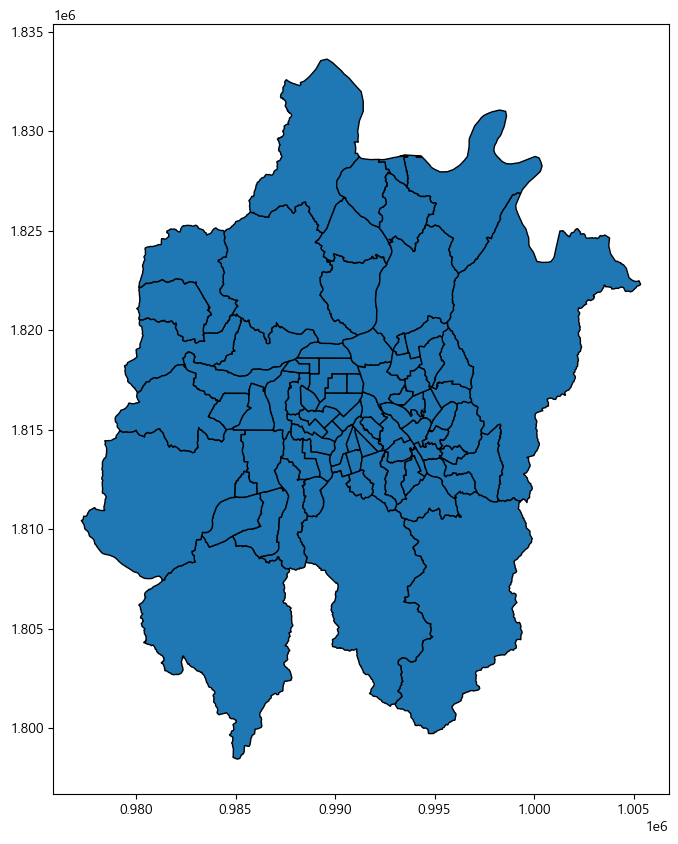

In [68]:
# 행정동 코드를 문자열로 변환
boundary["ADM_CD"] = boundary["ADM_CD"].astype(str)

# 대전 행정동만 추출
daejeon_boundary = boundary[
    boundary["ADM_CD"].str.startswith("25")
].copy()

print("대전 행정동 개수:", len(daejeon_boundary))

display(
    daejeon_boundary[
        ["ADM_CD", "ADM_NM"]
    ].head(20)
)

daejeon_boundary.plot(
    figsize=(10, 10),
    edgecolor="black"
)

## 대전 filtering 하기

In [69]:
print("변환 전 좌표계:", daejeon_boundary.crs)

daejeon_boundary = daejeon_boundary.to_crs(epsg=4326)

print("변환 후 좌표계:", daejeon_boundary.crs)

변환 전 좌표계: EPSG:5179
변환 후 좌표계: EPSG:4326


In [70]:
daejeon_boundary.to_file(
    "../data/processed/daejeon_boundary.geojson",
    driver="GeoJSON",
    encoding="utf-8"
)

print("대전 행정동 경계 저장 완료")

대전 행정동 경계 저장 완료


# F. 인구 데이터 확인

In [71]:
import pandas as pd
import geopandas as gpd

population = pd.read_csv(
    "../data/processed/population_dong.csv",
    encoding="utf-8-sig"
)

apt = pd.read_csv(
    "../data/processed/apt_all.csv",
    encoding="utf-8-sig"
)

postoffice = pd.read_csv(
    "../data/processed/postoffice_daejeon.csv",
    encoding="utf-8-sig"
)

boundary = gpd.read_file(
    "../data/processed/daejeon_boundary.geojson"
)

print(population.columns.tolist())
print(apt.columns.tolist())
print(postoffice.columns.tolist())
print(boundary.columns.tolist())

['행정기관코드', '구', '행정동', '총 인구수']
['공동주택명', '주소', '세대수', '구']
['관내우체국명', '우체국우편번호', '우체국주소', '우체국전화번호', '우편영업시간', '금융영업시간', '구']
['BASE_DATE', 'ADM_CD', 'ADM_NM', 'geometry']


## 공동주택과 우체국 행정동으로 변경

In [72]:
apt["행정동_추정"] = apt["주소"].str.extract(
    r"\s([가-힣0-9]+(?:동|읍|면))"
)

postoffice["행정동_추정"] = postoffice["우체국주소"].str.extract(
    r"\s([가-힣0-9]+(?:동|읍|면))"
)

display(
    apt[["공동주택명", "주소", "행정동_추정"]].head(20)
)

display(
    postoffice[
        ["관내우체국명", "우체국주소", "행정동_추정"]
    ].head(20)
)

,공동주택명,주소,행정동_추정
0,현대아파트,대전광역시 동구 계족로443번길 24(용전동),NaN
1,용전서민아파트,대전광역시 동구 계족로 485-35(용전동),NaN
2,삼성아파트A동,대전광역시 동구 선화로 183(삼성동),NaN
3,삼성아파트B동,대전광역시 동구 대전천동로 612(삼성동),대전천동
4,가양글로벌아파트,대전광역시 동구 동서대로1778번길 122(가양동),NaN
5,빌라맨션,대전광역시 동구 대전천동로 618(삼성동),대전천동
6,백조아파트,대전광역시 동구 흥룡로71번길 109(가양동),NaN
7,대동연립,대전광역시 동구 동대전로104번길 29 / 29-1 (대동),NaN
8,가양시장아파트,대전광역시 동구 매봉로 18(가양동),NaN
9,한산아파트,대전광역시 동구 흥룡로 40(가양동),NaN


,관내우체국명,우체국주소,행정동_추정
0,대전목동우체국,대전 중구 동서대로 1411(목동),NaN
1,대전호동우체국,대전 중구 대종로 150(호동),NaN
2,대전옥계동우편취급국,대전 중구 모암로7번길 150(옥계동),NaN
3,대전용두2동우편취급국,대전 중구 동서대로1321번길 19(용두동),NaN
4,한밭산성우편취급국,대전 중구 대둔산로 345(사정동),NaN
5,대전유성우체국,대전 유성구 온천로 51 (봉명동),NaN
6,대전성모병원우편취급국,대전 중구 대흥로 64(대흥동),NaN
7,대전둔산2동우체국,대전 서구 청사로 279 (둔산동),NaN
8,대전만년동우체국,대전 서구 만년로 15 (만년동),NaN
9,대전갈마동우체국,대전 서구 갈마중로50번길 5 (갈마동),NaN


# 추출 성공률 확인

In [73]:
print(
    "공동주택 행정동 추출 성공률:",
    apt["행정동_추정"].notna().mean()
)

print(
    "우체국 행정동 추출 성공률:",
    postoffice["행정동_추정"].notna().mean()
)

공동주택 행정동 추출 성공률: 0.0779816513761468
우체국 행정동 추출 성공률: 0.12222222222222222


## 추출 성공률이 낮으므로 다시 추출 동읍면  (주소에서)

In [74]:
import re

def extract_dong(address):
    if pd.isna(address):
        return None

    matches = re.findall(r'([가-힣0-9]+(?:동|읍|면|가))', str(address))

    if not matches:
        return None

    return matches[-1]

In [75]:
apt["주소동"] = apt["주소"].apply(extract_dong)

postoffice["주소동"] = postoffice["우체국주소"].apply(extract_dong)

display(apt[["공동주택명", "주소", "주소동"]].head(20))
display(postoffice[["관내우체국명", "우체국주소", "주소동"]].head(20))

,공동주택명,주소,주소동
0,현대아파트,대전광역시 동구 계족로443번길 24(용전동),용전동
1,용전서민아파트,대전광역시 동구 계족로 485-35(용전동),용전동
2,삼성아파트A동,대전광역시 동구 선화로 183(삼성동),삼성동
3,삼성아파트B동,대전광역시 동구 대전천동로 612(삼성동),삼성동
4,가양글로벌아파트,대전광역시 동구 동서대로1778번길 122(가양동),가양동
5,빌라맨션,대전광역시 동구 대전천동로 618(삼성동),삼성동
6,백조아파트,대전광역시 동구 흥룡로71번길 109(가양동),가양동
7,대동연립,대전광역시 동구 동대전로104번길 29 / 29-1 (대동),대동
8,가양시장아파트,대전광역시 동구 매봉로 18(가양동),가양동
9,한산아파트,대전광역시 동구 흥룡로 40(가양동),가양동


,관내우체국명,우체국주소,주소동
0,대전목동우체국,대전 중구 동서대로 1411(목동),목동
1,대전호동우체국,대전 중구 대종로 150(호동),호동
2,대전옥계동우편취급국,대전 중구 모암로7번길 150(옥계동),옥계동
3,대전용두2동우편취급국,대전 중구 동서대로1321번길 19(용두동),용두동
4,한밭산성우편취급국,대전 중구 대둔산로 345(사정동),사정동
5,대전유성우체국,대전 유성구 온천로 51 (봉명동),봉명동
6,대전성모병원우편취급국,대전 중구 대흥로 64(대흥동),대흥동
7,대전둔산2동우체국,대전 서구 청사로 279 (둔산동),둔산동
8,대전만년동우체국,대전 서구 만년로 15 (만년동),만년동
9,대전갈마동우체국,대전 서구 갈마중로50번길 5 (갈마동),갈마동


## 추출률 확인

In [76]:
print("아파트 동 추출률:", apt["주소동"].notna().mean())
print("우체국 동 추출률:", postoffice["주소동"].notna().mean())

아파트 동 추출률: 0.680045871559633
우체국 동 추출률: 0.7444444444444445


많이 좋진 않지만 이정도면 그래도 전보단 추출률이 상당히 많이 올라갔다.그대로 진행해도 될거같다.

# 경계 데이터 행정명과 직접 비교

In [77]:
boundary_dongs = set(daejeon_boundary["ADM_NM"].dropna())

apt["행정동"] = apt["주소동"].where(
    apt["주소동"].isin(boundary_dongs)
)

postoffice["행정동"] = postoffice["주소동"].where(
    postoffice["주소동"].isin(boundary_dongs)
)

In [78]:
print("아파트 직접 매칭률:", apt["행정동"].notna().mean())
print("우체국 직접 매칭률:", postoffice["행정동"].notna().mean())

아파트 직접 매칭률: 0.2717889908256881
우체국 직접 매칭률: 0.2777777777777778


직접 매칭률은 조금 아쉽다

## 불일치 목록 확인

In [79]:
apt_unmatched = apt[
    apt["행정동"].isna()
][["공동주택명", "주소", "주소동"]]

postoffice_unmatched = postoffice[
    postoffice["행정동"].isna()
][["관내우체국명", "우체국주소", "주소동"]]

display(apt_unmatched.head(30))
display(postoffice_unmatched.head(30))

,공동주택명,주소,주소동
4,가양글로벌아파트,대전광역시 동구 동서대로1778번길 122(가양동),가양동
6,백조아파트,대전광역시 동구 흥룡로71번길 109(가양동),가양동
8,가양시장아파트,대전광역시 동구 매봉로 18(가양동),가양동
9,한산아파트,대전광역시 동구 흥룡로 40(가양동),가양동
11,예지아파트,대전광역시 동구 비래서로42번길 69(가양동),가양동
15,수정아파트,대전광역시 동구 비래서로62번길 57(가양동),가양동
19,평화맨션,대전광역시 동구 계족로382번길 125(가양동),가양동
20,한밭빌라,대전광역시 동구 흥룡로71번길 115(가양동),가양동
21,흥룡연립,대전광역시 동구 우암로291번길 40(가양동),가양동
22,한성잉꼬아파트,대전광역시 동구 동대전로321번길 9(가양동),가양동


,관내우체국명,우체국주소,주소동
1,대전호동우체국,대전 중구 대종로 150(호동),호동
2,대전옥계동우편취급국,대전 중구 모암로7번길 150(옥계동),옥계동
4,한밭산성우편취급국,대전 중구 대둔산로 345(사정동),사정동
5,대전유성우체국,대전 유성구 온천로 51 (봉명동),봉명동
7,대전둔산2동우체국,대전 서구 청사로 279 (둔산동),둔산동
9,대전갈마동우체국,대전 서구 갈마중로50번길 5 (갈마동),갈마동
11,대전관저동우체국,대전 서구 관저북로 26 (관저동),관저동
12,대전월평1동우체국,대전 서구 월평새뜸로4번길 110 (월평동),월평동
13,정부대전청사우체국,"대전 서구 청사로 189, 민원동에서 방문증 발급 후 이용가능",이용가
14,대전관저2동우체국,대전 서구 관저로 63 (관저동),관저동


## 최종매칭률 확인


In [80]:
print("아파트 최종 매칭률:", apt["행정동"].notna().mean())
print("우체국 최종 매칭률:", postoffice["행정동"].notna().mean())

아파트 최종 매칭률: 0.2717889908256881
우체국 최종 매칭률: 0.2777777777777778


# 매칭된 데이터만 분리

In [81]:
apt_matched = apt[apt["행정동"].notna()].copy()
postoffice_matched = postoffice[postoffice["행정동"].notna()].copy()

print("매칭된 아파트 수:", len(apt_matched))
print("매칭된 우체국 수:", len(postoffice_matched))

매칭된 아파트 수: 237
매칭된 우체국 수: 25


## 행정동별 집계

In [82]:
apt_by_dong = (
    apt_matched
    .groupby(["구", "행정동"], as_index=False)
    .agg(
        공동주택수=("공동주택명", "count"),
        공동주택세대수=("세대수", "sum")
    )
)

postoffice_by_dong = (
    postoffice_matched
    .groupby(["구", "행정동"], as_index=False)
    .size()
    .rename(columns={"size": "우체국수"})
)

## 인구데이터와 merge

In [83]:
final_data = population.merge(
    apt_by_dong,
    on=["구", "행정동"],
    how="left"
)

final_data = final_data.merge(
    postoffice_by_dong,
    on=["구", "행정동"],
    how="left"
)

fill_cols = [
    "공동주택수",
    "공동주택세대수",
    "우체국수"
]

final_data[fill_cols] = final_data[fill_cols].fillna(0)

display(final_data.head())
print(final_data.shape)

,행정기관코드,구,행정동,총 인구수,공동주택수,공동주택세대수,우체국수
0,3011051500,동구,중앙동,3319,0.0,0.0,0.0
1,3011053000,동구,효동,29264,1.0,1056.0,0.0
2,3011054500,동구,신인동,14713,0.0,0.0,0.0
3,3011055100,동구,판암1동,11650,0.0,0.0,0.0
4,3011055200,동구,판암2동,7647,0.0,0.0,0.0


(78, 7)


사용할 변수 선택 
우리가 현재 가지고 있는 데이터 
인구 / 수요/높을수록 좋음
공동주택세대수/ 잠재수요 /높을수록 좋음
우체국수/기존공급/적을수록 좋음


# minmax 정규화

In [85]:
print(final_data.columns)

Index(['행정기관코드', '구', '행정동', '총 인구수', '공동주택수', '공동주택세대수', '우체국수'], dtype='str')


In [86]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ["총 인구수", "공동주택세대수", "우체국수"]

final_data[cols] = final_data[cols].fillna(0)

final_data[["인구_norm",
            "세대수_norm",
            "우체국_norm"]] = scaler.fit_transform(
    final_data[cols]
)

# 입지 점수 계산

In [87]:
final_data["입지점수"] = (
      0.4*final_data["인구_norm"]
    + 0.4*final_data["세대수_norm"]
    - 0.2*final_data["우체국_norm"]
)

## 순위

In [88]:
ranking = (
    final_data
    .sort_values("입지점수", ascending=False)
    .reset_index(drop=True)
)

ranking.head(10)

,행정기관코드,구,행정동,총 인구수,공동주택수,공동주택세대수,우체국수,인구_norm,세대수_norm,우체국_norm,입지점수
0,3020061000,유성구,원신흥동,30613,8.0,8009.0,0.0,0.631875,0.980054,0.000000,0.644772
1,3020052700,유성구,상대동,25011,9.0,8172.0,0.0,0.507786,1.000000,0.000000,0.603114
2,3023054300,대덕구,송촌동,26885,14.0,7514.0,1.0,0.549297,0.919481,0.333333,0.520844
3,3017059300,서구,도안동,36459,5.0,6995.0,2.0,0.761369,0.855972,0.666667,0.513603
4,3020057000,유성구,전민동,25318,4.0,6504.0,1.0,0.514586,0.795888,0.333333,0.457523
5,3011056000,동구,용운동,20851,8.0,5805.0,0.0,0.415638,0.710352,0.000000,0.450396
6,3017059700,서구,관저2동,47232,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.400000
7,3023056000,대덕구,석봉동,15700,12.0,4793.0,0.0,0.301539,0.586515,0.000000,0.355222
8,3020054000,유성구,온천2동,40733,0.0,0.0,0.0,0.856042,0.000000,0.000000,0.342417
9,3011064000,동구,용전동,19473,12.0,3437.0,0.0,0.385115,0.420582,0.000000,0.322279


# csv 저장

In [89]:
ranking.to_csv(
    "../data/processed/location_ranking.csv",
    index=False,
    encoding="utf-8-sig"
)

# 그래프

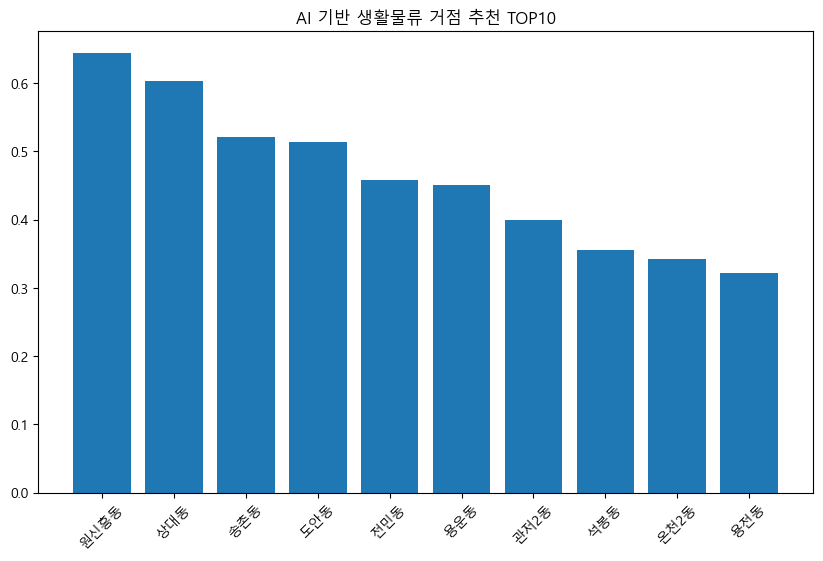

In [90]:
import matplotlib.pyplot as plt

top10 = ranking.head(10)

plt.figure(figsize=(10,6))

plt.bar(top10["행정동"], top10["입지점수"])

plt.xticks(rotation=45)

plt.title("AI 기반 생활물류 거점 추천 TOP10")

plt.show()

# ranking 과 경계 merge

In [91]:
import geopandas as gpd

boundary = gpd.read_file("../data/processed/daejeon_boundary.geojson")

boundary = boundary.rename(columns={
    "ADM_NM": "행정동"
})

map_data = boundary.merge(
    ranking,
    on="행정동",
    how="left"
)

map_data.head()

,BASE_DATE,ADM_CD,행정동,geometry,행정기관코드,구,총 인구수,공동주택수,공동주택세대수,우체국수,인구_norm,세대수_norm,우체국_norm,입지점수
0,20250630,25010530,효동,"POLYGON ((127.44675 36.31952, 127.4468 36.3195...",3.011053e+09,동구,29264.0,1.0,1056.0,0.0,0.601994,0.129222,0.0,0.292486
1,20250630,25010550,판암1동,"POLYGON ((127.48133 36.33414, 127.48109 36.333...",3.011055e+09,동구,11650.0,0.0,0.0,0.0,0.211829,0.000000,0.0,0.084731
2,20250630,25010560,판암2동,"POLYGON ((127.45846 36.32515, 127.45855 36.325...",3.011055e+09,동구,7647.0,0.0,0.0,0.0,0.123159,0.000000,0.0,0.049263
3,20250630,25010570,용운동,"POLYGON ((127.46314 36.34467, 127.4634 36.3446...",3.011056e+09,동구,20851.0,8.0,5805.0,0.0,0.415638,0.710352,0.0,0.450396
4,20250630,25010600,자양동,"POLYGON ((127.45367 36.34497, 127.45367 36.344...",3.011059e+09,동구,10641.0,5.0,897.0,0.0,0.189478,0.109765,0.0,0.119697


# 좌표계 확인

In [92]:
print(map_data.crs)

EPSG:4326


# 입지 점수 지도

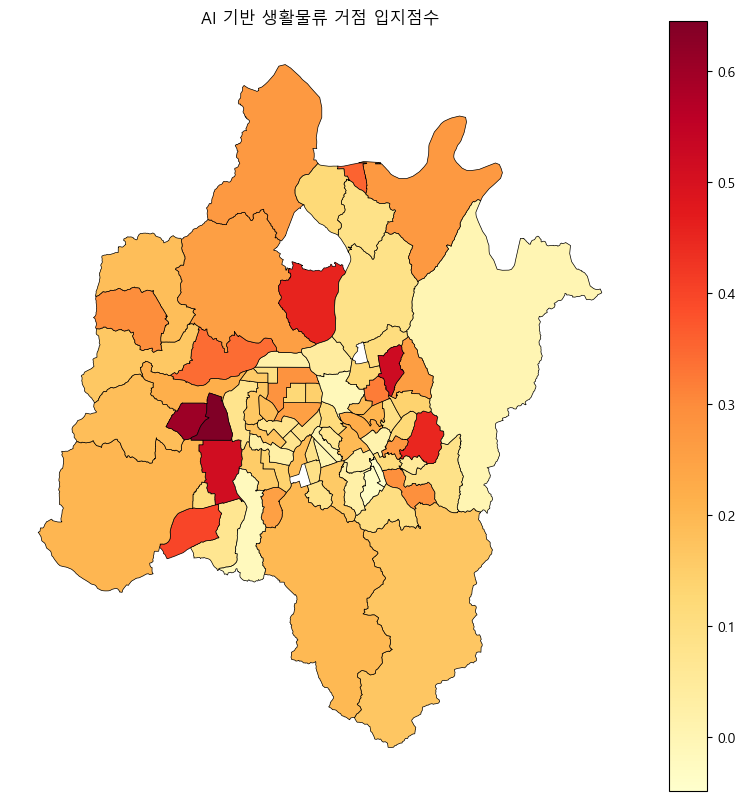

In [93]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

map_data.plot(
    column="입지점수",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("AI 기반 생활물류 거점 입지점수")

ax.axis("off")

plt.show()

# 탑10 위치 표시

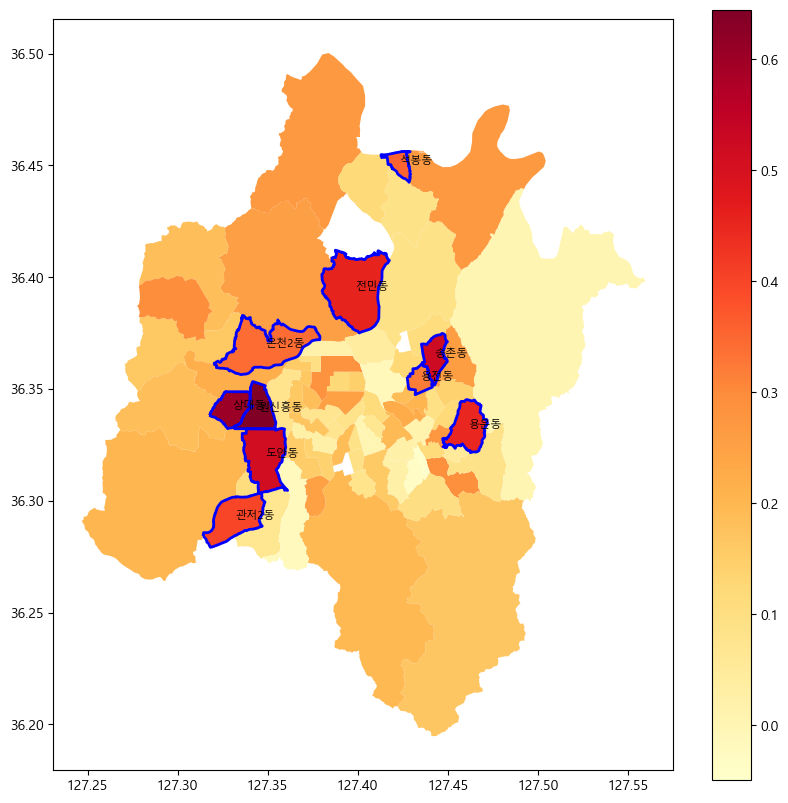

In [94]:
top10 = map_data.nlargest(10, "입지점수")

fig, ax = plt.subplots(figsize=(10,10))

map_data.plot(
    column="입지점수",
    cmap="YlOrRd",
    legend=True,
    ax=ax
)

top10.boundary.plot(
    ax=ax,
    linewidth=2,
    color="blue"
)

for idx, row in top10.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    ax.text(
        x,
        y,
        row["행정동"],
        fontsize=8
    )

plt.show()

#저장

In [95]:
map_data.to_file(
    "../data/processed/location_map.geojson",
    driver="GeoJSON"
)